# Exploratory Data Analysis (EDA)
## Dataset: installments_payments

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `installments_payments` dataset from the Home Credit risk modeling case. This table contains repayment history for previously disbursed credits at Home Credit, capturing both payments made and missed installments as behavioral signals for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `installments_payments` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (installments_payments to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of installment payment behavior

---

## 🧠 Key Questions
- What is the installment payment behavior profile of current applicants?
- How do payment delays and underpayments relate to default behavior?
- What aggregated signals from installment history are most predictive of default?
- Are there patterns in missed or late payments that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated installment payment features ready for merging into the main modeling table
- Business insights on repayment behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [3]:
# Dataset installments_payments
installments_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\installments_payments.csv'
df_installments = pd.read_csv(installments_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

The dataset consists of **13,605,401 observations** and **8 features**, representing the repayment history of previously disbursed credits at Home Credit. Each row corresponds to either a payment made or a missed installment, linked to an applicant via `SK_ID_CURR` and to a specific previous loan via `SK_ID_PREV`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_PREV` (link to previous_application) and `SK_ID_CURR` (link to main table)
- **Installment identifiers**: `NUM_INSTALMENT_VERSION` (version of installment schedule) and `NUM_INSTALMENT_NUMBER` (installment sequence number)
- **Temporal features**: `DAYS_INSTALMENT` (scheduled payment day) and `DAYS_ENTRY_PAYMENT` (actual payment day), both relative to application date
- **Amount features**: `AMT_INSTALMENT` (scheduled payment amount) and `AMT_PAYMENT` (actual payment amount)

In [4]:
df_installments.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


# 2. Payment Behavior Overview

This section provides an initial overview of payment behavior by examining the proportion of late payments and underpayments across all installment records. Understanding the overall payment discipline profile serves as a foundation before detailed feature analysis.

- Total Records: 13,605,401
- On-time or Early Payments: 12,455,827 (~91.55%)
- Late Payments: 1,146,669 (~8.43%)
- Underpayments: 1,295,493 (~9.52%)

The majority of installment payments are made **on-time or early (~91.55%)**, reflecting generally disciplined repayment behavior across the portfolio. However, **8.43% of payments are late** and **9.52% are underpayments**, representing meaningful delinquency signals. Notably, the late payment rate (~8.43%) closely mirrors the overall default rate in `application_train` (~8.1%), suggesting installment payment behavior is strongly aligned with default risk.

In [5]:
# Derive payment delay and payment difference
df_installments['DAYS_PAYMENT_DIFF'] = df_installments['DAYS_ENTRY_PAYMENT'] - df_installments['DAYS_INSTALMENT']
df_installments['AMT_PAYMENT_DIFF'] = df_installments['AMT_INSTALMENT'] - df_installments['AMT_PAYMENT']

# Late payments: actual payment day is after scheduled day (positive diff)
late_payments = (df_installments['DAYS_PAYMENT_DIFF'] > 0).sum()
late_pct = late_payments / len(df_installments) * 100

# Underpayments: actual payment is less than scheduled amount (positive diff)
underpayments = (df_installments['AMT_PAYMENT_DIFF'] > 0).sum()
underpayment_pct = underpayments / len(df_installments) * 100

# On-time payments
on_time = (df_installments['DAYS_PAYMENT_DIFF'] <= 0).sum()
on_time_pct = on_time / len(df_installments) * 100

print(f"Total Records          : {len(df_installments):,}")
print(f"Late Payments          : {late_payments:,} ({late_pct:.2f}%)")
print(f"On-time or Early       : {on_time:,} ({on_time_pct:.2f}%)")
print(f"Underpayments          : {underpayments:,} ({underpayment_pct:.2f}%)")

Total Records          : 13,605,401
Late Payments          : 1,146,669 (8.43%)
On-time or Early       : 12,455,827 (91.55%)
Underpayments          : 1,295,493 (9.52%)


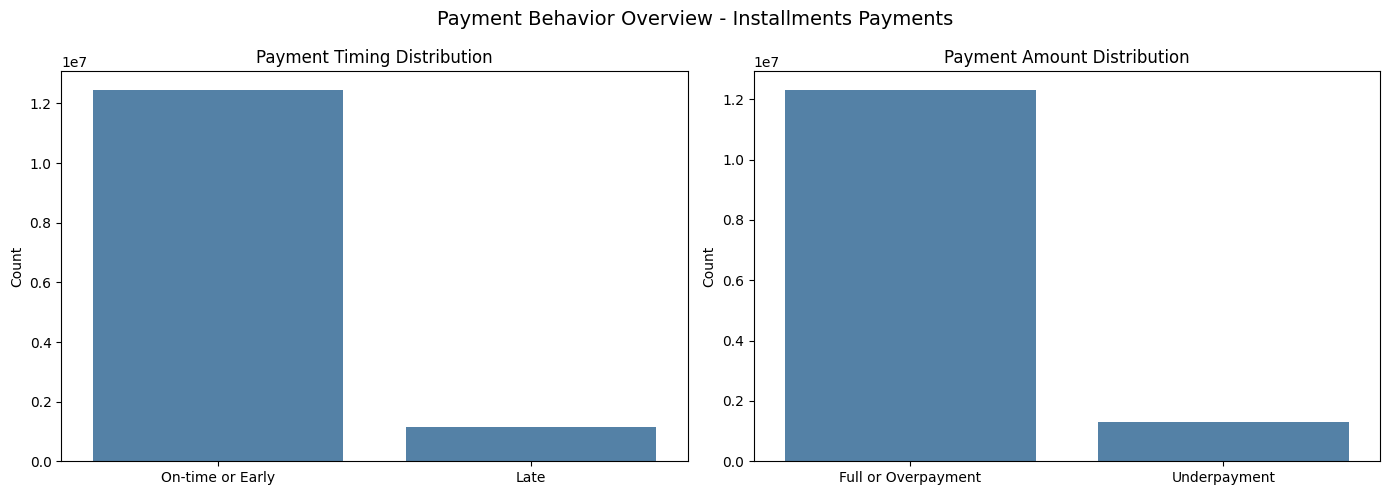

In [6]:
# Bar plot - payment behavior overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Late vs on-time
payment_timing = ['On-time or Early', 'Late']
payment_timing_counts = [on_time, late_payments]
sns.barplot(x=payment_timing, y=payment_timing_counts, ax=axes[0], color='steelblue')
axes[0].set_title('Payment Timing Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

# Underpayment vs full payment
payment_amount = ['Full or Overpayment', 'Underpayment']
payment_amount_counts = [
    (df_installments['AMT_PAYMENT_DIFF'] <= 0).sum(),
    underpayments
]
sns.barplot(x=payment_amount, y=payment_amount_counts, ax=axes[1], color='steelblue')
axes[1].set_title('Payment Amount Distribution')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')

plt.suptitle('Payment Behavior Overview - Installments Payments', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

In [7]:
# Missing value count and percentage
missing_inst = pd.DataFrame({
    'Missing Count': df_installments.isnull().sum(),
    'Missing (%)': (df_installments.isnull().sum() / len(df_installments) * 100).round(2)
})
missing_inst = missing_inst[missing_inst['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

if missing_inst.empty:
    print("No missing values found in installments_payments.")
else:
    print(missing_inst)

                    Missing Count  Missing (%)
DAYS_ENTRY_PAYMENT           2905         0.02
AMT_PAYMENT                  2905         0.02
DAYS_PAYMENT_DIFF            2905         0.02
AMT_PAYMENT_DIFF             2905         0.02


### Key Findings & Handling Strategy

The `installments_payments` dataset contains **4 features with missing values**, all with negligible missing rates. Note that `DAYS_PAYMENT_DIFF` and `AMT_PAYMENT_DIFF` are derived features created in Section 2, so their missing values are inherited from `DAYS_ENTRY_PAYMENT` and `AMT_PAYMENT` respectively.

Key observations:
- `DAYS_ENTRY_PAYMENT` and `AMT_PAYMENT` (0.02%) are missing together for the same 2,905 rows, likely representing missed installments where no payment was made and therefore no entry date or amount was recorded.

**Handling Strategy:**
- `DAYS_ENTRY_PAYMENT`: impute with `DAYS_INSTALMENT` + a large penalty value (e.g. 365) to signal missed payment, or flag separately as `IS_MISSED_PAYMENT` binary indicator
- `AMT_PAYMENT`: impute with **0**, missing indicates no payment was made for that installment
- `DAYS_PAYMENT_DIFF`, `AMT_PAYMENT_DIFF`: will be resolved automatically after imputing the source features above
---

# 4. Numerical Features Analysis

Numerical features in `installments_payments` are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

In [8]:
# Numerical features in installments_payments (exclude identifiers)
num_cols_inst = df_installments.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_inst = [col for col in num_cols_inst if col not in ['SK_ID_PREV', 'SK_ID_CURR']]

## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [9]:
# Statistical description
df_installments[num_cols_inst].describe().T

,count,mean,std,min,25%,50%,75%,max
NUM_INSTALMENT_VERSION,13605401.0,0.856637,1.035216,0.000,0.000,1.000,1.000,178.000
NUM_INSTALMENT_NUMBER,13605401.0,18.870896,26.664067,1.000,4.000,8.000,19.000,277.000
DAYS_INSTALMENT,13605401.0,-1042.269992,800.946284,-2922.000,-1654.000,-818.000,-361.000,-1.000
DAYS_ENTRY_PAYMENT,13602496.0,-1051.113684,800.585883,-4921.000,-1662.000,-827.000,-370.000,-1.000
AMT_INSTALMENT,13605401.0,17050.906989,50570.254429,0.000,4226.085,8884.080,16710.210,3771487.845
AMT_PAYMENT,13602496.0,17238.223250,54735.783981,0.000,3398.265,8125.515,16108.425,3771487.845
DAYS_PAYMENT_DIFF,13602496.0,-8.787405,25.539900,-3189.000,-14.000,-6.000,0.000,2884.000
AMT_PAYMENT_DIFF,13602496.0,-187.153772,19106.732113,-2630908.935,0.000,0.000,0.000,2424726.405


##### Key Findings

**Days Features (Negative Values by Design)**
`DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT` are negative by design, representing days relative to application date. No transformation needed in EDA.

**Anomalies Detected**
- `DAYS_ENTRY_PAYMENT` min = **-4,921**, more negative than `DAYS_INSTALMENT` min of -2,922, suggesting some payments were recorded earlier than the earliest scheduled installment. Requires investigation.
- `DAYS_PAYMENT_DIFF` max = **2,884**, indicating extreme late payments of nearly 8 years. Requires capping before aggregation.
- `DAYS_PAYMENT_DIFF` min = **-3,189**, indicating extreme early payments. Likely anomalous and requires investigation.
- `AMT_PAYMENT_DIFF` min = **-2,630,908** and max = **2,424,726**, extreme values on both ends. Negative values indicate overpayments while positive values indicate underpayments. Both extremes require capping.
- `NUM_INSTALMENT_VERSION` max = **178**, extreme outlier suggesting a loan with 178 restructuring versions. Requires investigation.

**Derived Features (Section 2)**
- `DAYS_PAYMENT_DIFF` mean = -8.79 and median = -6, confirming most payments are made slightly early on average. Positive values indicate late payments.
- `AMT_PAYMENT_DIFF` median = 0, confirming most installments are paid in full. Positive values indicate underpayments.

**Skewed Distributions**
- `AMT_INSTALMENT` mean 17,051 vs median 8,884, heavily right-skewed. Max of 3,771,488 confirms extreme outliers.
- `AMT_PAYMENT` shows similar pattern with mean 17,238 vs median 8,126.
- `NUM_INSTALMENT_NUMBER` mean 18.87 vs median 8, heavily right-skewed reflecting varying loan term lengths.

**Features for Further Analysis**
- `DAYS_PAYMENT_DIFF` to confirm distribution of payment delays
- `AMT_PAYMENT_DIFF` to examine underpayment and overpayment patterns
- `AMT_INSTALMENT` and `AMT_PAYMENT` to confirm skewness and outlier severity

---

### 4.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

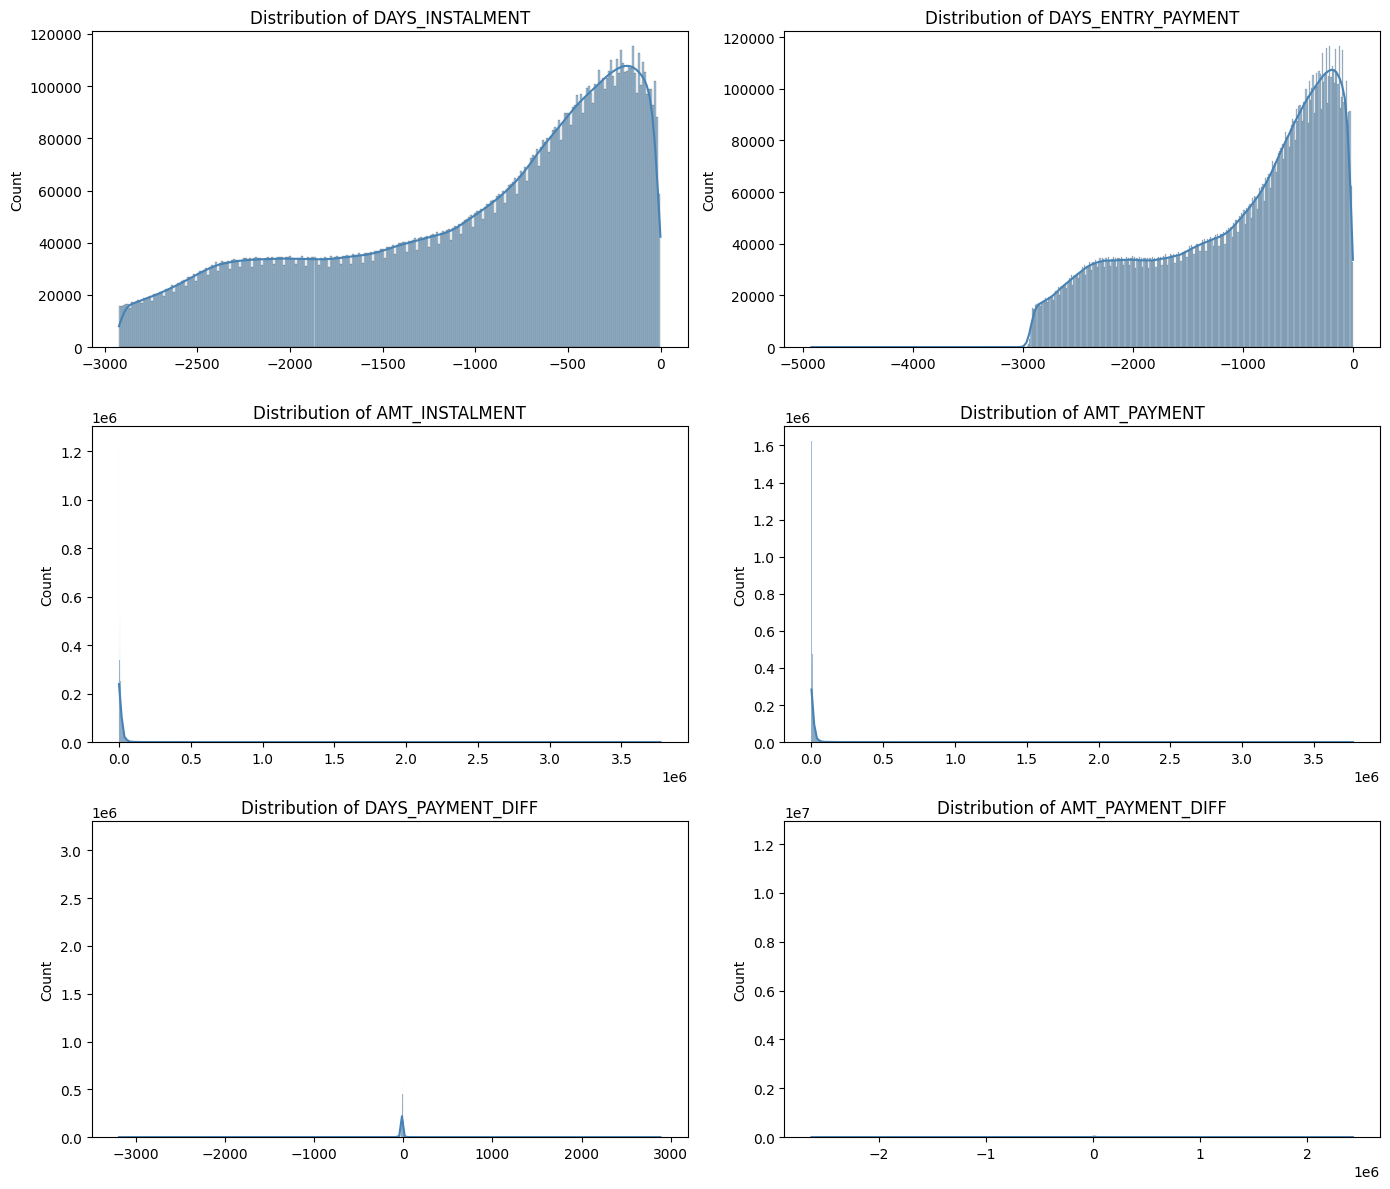

In [10]:
# Select key numerical features for distribution analysis
num_features_dist = [
    'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
    'AMT_INSTALMENT', 'AMT_PAYMENT',
    'DAYS_PAYMENT_DIFF', 'AMT_PAYMENT_DIFF'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_features_dist):
    sns.histplot(df_installments[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

##### Key Findings

- `DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT` show similar left-skewed distributions concentrated near 0, confirming most installment records are recent relative to application date. `DAYS_ENTRY_PAYMENT` extends further left to -4,921, confirming the anomalous early payment records noted in stat desc.
- `AMT_INSTALMENT` and `AMT_PAYMENT` are both extremely right-skewed with the vast majority compressed near zero and long tails extending to 3.7M. Both show near-identical distribution shapes, confirming most payments match their scheduled amounts. **Capping recommended.**
- `DAYS_PAYMENT_DIFF` is sharply concentrated near 0 with symmetric tails extending to -3,189 (early) and +2,884 (late), confirming most payments are made close to schedule. The distribution is slightly left-skewed, consistent with the mean of -8.79 days indicating payments tend to be made slightly early.
- `AMT_PAYMENT_DIFF` is heavily compressed near 0 with extreme outliers on both sides extending to -2.6M (overpayment) and +2.4M (underpayment). The vast majority of installments are paid in full. **Capping recommended.**

---

### 4.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

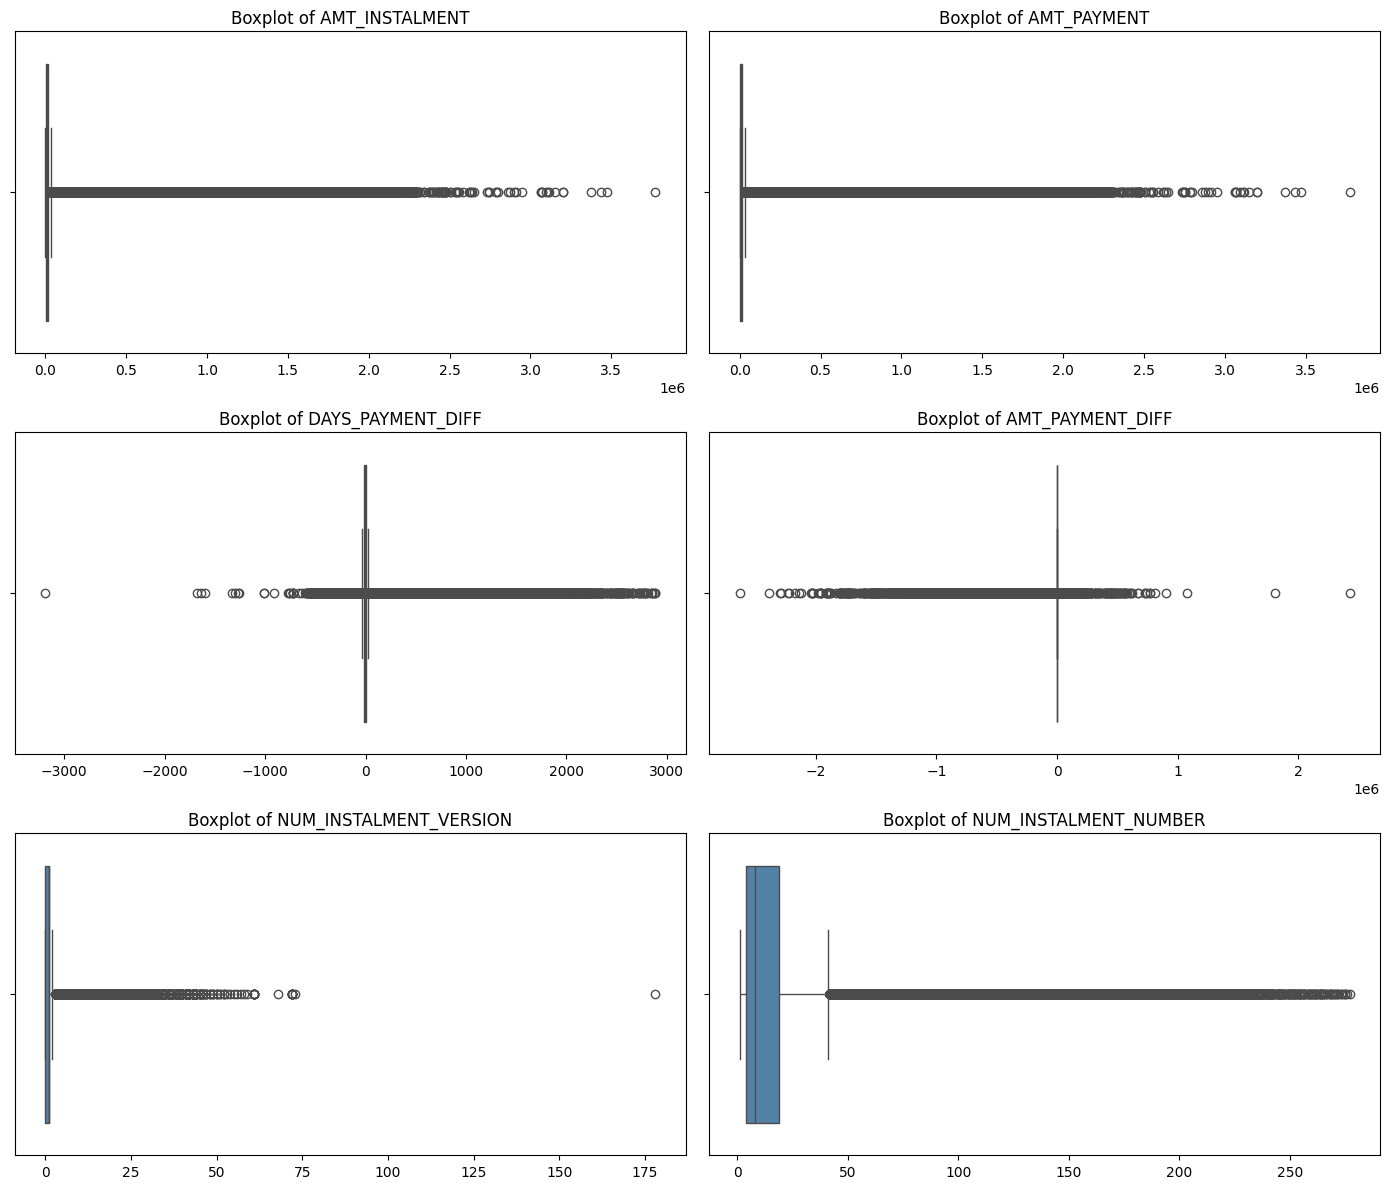

In [11]:
# Select key numerical features for outlier detection
outlier_features = [
    'AMT_INSTALMENT', 'AMT_PAYMENT',
    'DAYS_PAYMENT_DIFF', 'AMT_PAYMENT_DIFF',
    'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_installments[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


##### Key Findings

- `AMT_INSTALMENT` and `AMT_PAYMENT` show extreme outliers extending to 3.7M with IQR compressed near zero, **needs capping.**
- `DAYS_PAYMENT_DIFF` shows extreme outliers on both sides (-3,189 to +2,884), **needs capping at both tails.**
- `AMT_PAYMENT_DIFF` shows extreme outliers on both sides extending to 2.4M, **needs capping at both tails.**
- `NUM_INSTALMENT_VERSION` shows extreme outlier at 178, **needs investigation and capping.**
- `NUM_INSTALMENT_NUMBER` shows moderate spread up to 277 with sparse outliers, reasonable range for long-term loans.

All derived features and amount features require outlier treatment before aggregation. Special attention needed for bilateral outliers in `DAYS_PAYMENT_DIFF` and `AMT_PAYMENT_DIFF`.

---

## 4.2 Bivariate Between Features

This section examines pairwise correlations between numerical features in `installments_payments` to detect multicollinearity and identify redundant features before aggregation.

The approach includes:
- **Heatmap** to visualize pairwise correlation between numerical features

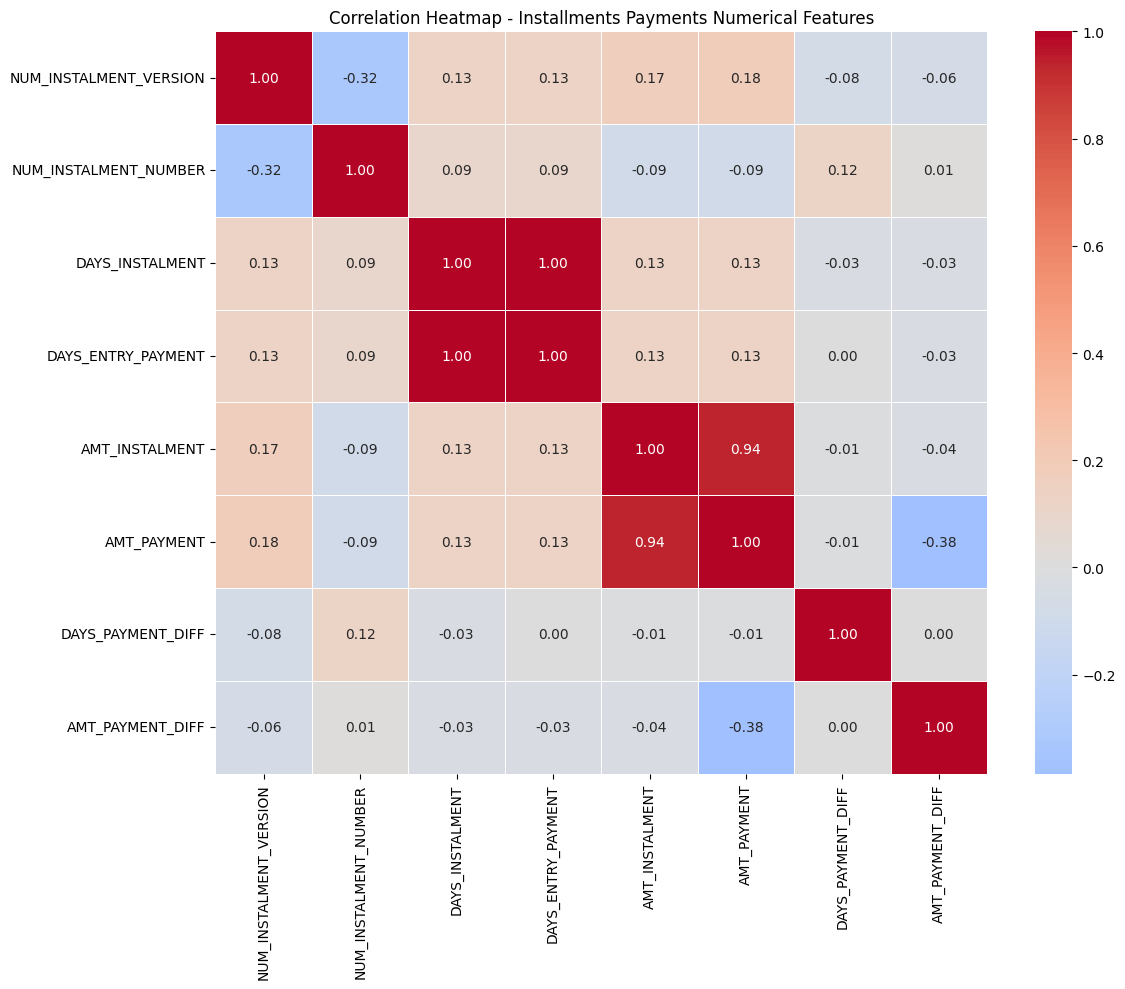

In [12]:
# Select relevant numerical features for correlation analysis
num_cols_corr = [
    'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER',
    'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
    'AMT_INSTALMENT', 'AMT_PAYMENT',
    'DAYS_PAYMENT_DIFF', 'AMT_PAYMENT_DIFF'
]

# Correlation heatmap - installments_payments numerical features
plt.figure(figsize=(12, 10))
corr_inst = df_installments[num_cols_corr].corr()
sns.heatmap(
    corr_inst,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap - Installments Payments Numerical Features')
plt.tight_layout()
plt.show()

#### Key Findings

**Perfect Correlation: Days Features**
`DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT` are perfectly correlated (1.00), which is expected as actual payment days closely follow scheduled days for the vast majority of records. During aggregation, retain both as their difference (`DAYS_PAYMENT_DIFF`) is the most informative derived feature.

**High Correlation: Amount Features**
`AMT_INSTALMENT` and `AMT_PAYMENT` show high correlation (0.94), confirming most payments match their scheduled amounts. `AMT_PAYMENT_DIFF` captures the deviation and is more informative than either raw feature alone for default prediction.

**Moderate Negative Correlation: AMT_PAYMENT and AMT_PAYMENT_DIFF**
`AMT_PAYMENT` and `AMT_PAYMENT_DIFF` show moderate negative correlation (-0.38), expected as higher payments naturally result in smaller underpayment differences.

**Moderate Negative Correlation: NUM_INSTALMENT_VERSION and NUM_INSTALMENT_NUMBER**
Both show moderate negative correlation (-0.32), suggesting loans with more restructuring versions tend to have lower installment numbers, possibly reflecting early-stage restructured loans.

**DPD-equivalent Features are Independent**
`DAYS_PAYMENT_DIFF` and `AMT_PAYMENT_DIFF` show near-zero correlation with all other features (max 0.12), confirming that payment behavior deviations are independent of loan size, timing, and installment structure. Both are valuable standalone features for aggregation.

**Features to Watch During Aggregation**
- `DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT`: retain both for recency features but focus aggregation on `DAYS_PAYMENT_DIFF`
- `AMT_INSTALMENT` and `AMT_PAYMENT`: retain both for ratio features but focus aggregation on `AMT_PAYMENT_DIFF`

---

# Aggregation

This section aggregates `installments_payments` into applicant-level features ready for merging into the main modeling table. Aggregation is performed in a single step directly to `SK_ID_CURR` level.

The approach includes:
- **Aggregating** `installments_payments` to `SK_ID_CURR` level to derive applicant-level installment payment behavior features

## Installments Payments to SK_ID_CURR

Installment payment records are aggregated to applicant level using `SK_ID_CURR` as the key. This produces one row per applicant containing summarized repayment behavior features ready for merging into `application_train`.

In [13]:
# Aggregate installments_payments to SK_ID_CURR level
df_inst_agg = df_installments.groupby('SK_ID_CURR').agg(
    # Record count
    INST_COUNT=('SK_ID_PREV', 'count'),
    INST_UNIQUE_LOANS=('SK_ID_PREV', 'nunique'),

    # Instalment number features
    INST_NUM_INSTALMENT_NUMBER_MAX=('NUM_INSTALMENT_NUMBER', 'max'),
    INST_NUM_INSTALMENT_NUMBER_MEAN=('NUM_INSTALMENT_NUMBER', 'mean'),

    # Days features
    INST_DAYS_INSTALMENT_MEAN=('DAYS_INSTALMENT', 'mean'),
    INST_DAYS_INSTALMENT_MAX=('DAYS_INSTALMENT', 'max'),
    INST_DAYS_ENTRY_PAYMENT_MEAN=('DAYS_ENTRY_PAYMENT', 'mean'),

    # Amount features
    INST_AMT_INSTALMENT_MEAN=('AMT_INSTALMENT', 'mean'),
    INST_AMT_INSTALMENT_SUM=('AMT_INSTALMENT', 'sum'),
    INST_AMT_PAYMENT_MEAN=('AMT_PAYMENT', 'mean'),
    INST_AMT_PAYMENT_SUM=('AMT_PAYMENT', 'sum'),

    # Payment diff features
    INST_DAYS_PAYMENT_DIFF_MEAN=('DAYS_PAYMENT_DIFF', 'mean'),
    INST_DAYS_PAYMENT_DIFF_MAX=('DAYS_PAYMENT_DIFF', 'max'),
    INST_DAYS_PAYMENT_DIFF_MIN=('DAYS_PAYMENT_DIFF', 'min'),
    INST_AMT_PAYMENT_DIFF_MEAN=('AMT_PAYMENT_DIFF', 'mean'),
    INST_AMT_PAYMENT_DIFF_MAX=('AMT_PAYMENT_DIFF', 'max'),
    INST_AMT_PAYMENT_DIFF_SUM=('AMT_PAYMENT_DIFF', 'sum'),
).reset_index()

In [15]:
# Late payment count and proportion
df_installments['IS_LATE'] = (df_installments['DAYS_PAYMENT_DIFF'] > 0).astype(int)
df_installments['IS_UNDERPAID'] = (df_installments['AMT_PAYMENT_DIFF'] > 0).astype(int)

late_agg = df_installments.groupby('SK_ID_CURR').agg(
    INST_LATE_COUNT=('IS_LATE', 'sum'),
    INST_UNDERPAID_COUNT=('IS_UNDERPAID', 'sum'),
).reset_index()

# Merge late payment features
df_inst_agg = df_inst_agg.merge(late_agg, on='SK_ID_CURR', how='left')

# Proportion features
df_inst_agg['INST_PROP_LATE'] = (df_inst_agg['INST_LATE_COUNT'] / df_inst_agg['INST_COUNT']).round(4)
df_inst_agg['INST_PROP_UNDERPAID'] = (df_inst_agg['INST_UNDERPAID_COUNT'] / df_inst_agg['INST_COUNT']).round(4)

# Payment ratio
df_inst_agg['INST_AMT_PAYMENT_RATIO'] = (
    df_inst_agg['INST_AMT_PAYMENT_SUM'] / df_inst_agg['INST_AMT_INSTALMENT_SUM']
).round(4)

# Binary flag features
df_inst_agg['INST_HAS_LATE'] = (df_inst_agg['INST_LATE_COUNT'] >= 1).astype(int)
df_inst_agg['INST_HAS_UNDERPAID'] = (df_inst_agg['INST_UNDERPAID_COUNT'] >= 1).astype(int)

print("Shape df_inst_agg:", df_inst_agg.shape)
df_inst_agg.head()

Shape df_inst_agg: (339587, 25)


,SK_ID_CURR,INST_COUNT,INST_UNIQUE_LOANS,INST_NUM_INSTALMENT_NUMBER_MAX,INST_NUM_INSTALMENT_NUMBER_MEAN,INST_DAYS_INSTALMENT_MEAN,INST_DAYS_INSTALMENT_MAX,INST_DAYS_ENTRY_PAYMENT_MEAN,INST_AMT_INSTALMENT_MEAN,INST_AMT_INSTALMENT_SUM,...,INST_AMT_PAYMENT_DIFF_MEAN,INST_AMT_PAYMENT_DIFF_MAX,INST_AMT_PAYMENT_DIFF_SUM,INST_AMT_PAYMENT_RATIO,INST_LATE_COUNT,INST_UNDERPAID_COUNT,INST_PROP_LATE,INST_PROP_UNDERPAID,INST_HAS_LATE,INST_HAS_UNDERPAID
0,100001,7,2,4,2.714286,-2187.714286,-1619.0,-2195.000000,5885.132143,41195.925,...,0.0,0.0,0.0,1.0,1,0,0.1429,0.0,1,0
1,100002,19,1,19,10.000000,-295.000000,-25.0,-315.421053,11559.247105,219625.695,...,0.0,0.0,0.0,1.0,0,0,0.0000,0.0,0,0
2,100003,25,3,12,5.080000,-1378.160000,-536.0,-1385.320000,64754.586000,1618864.650,...,0.0,0.0,0.0,1.0,0,0,0.0000,0.0,0,0
3,100004,3,1,3,2.000000,-754.000000,-724.0,-761.666667,7096.155000,21288.465,...,0.0,0.0,0.0,1.0,0,0,0.0000,0.0,0,0
4,100005,9,1,9,5.000000,-586.000000,-466.0,-609.555556,6240.205000,56161.845,...,0.0,0.0,0.0,1.0,1,0,0.1111,0.0,1,0


In [16]:
# Merge installments_payments aggregations with application_train
df_inst_agg_target = df_inst_agg.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

print("Shape df_inst_agg_target:", df_inst_agg_target.shape)

Shape df_inst_agg_target: (339587, 26)


# 5. Categorical Features Analysis
- No Cat Features


# 6. Bivariate Aggregated Features vs TARGET

This section examines the relationship between aggregated installment payment features and the target variable (`TARGET`). The goal is to identify which aggregated features carry the strongest signal for predicting loan default.

The approach includes:
- **KDE plots** to compare distributions of aggregated numerical features between default and non-default applicants
- **Default rate plots** to evaluate default rate per category for aggregated categorical features

## 6.1 Numerical Aggregated Features

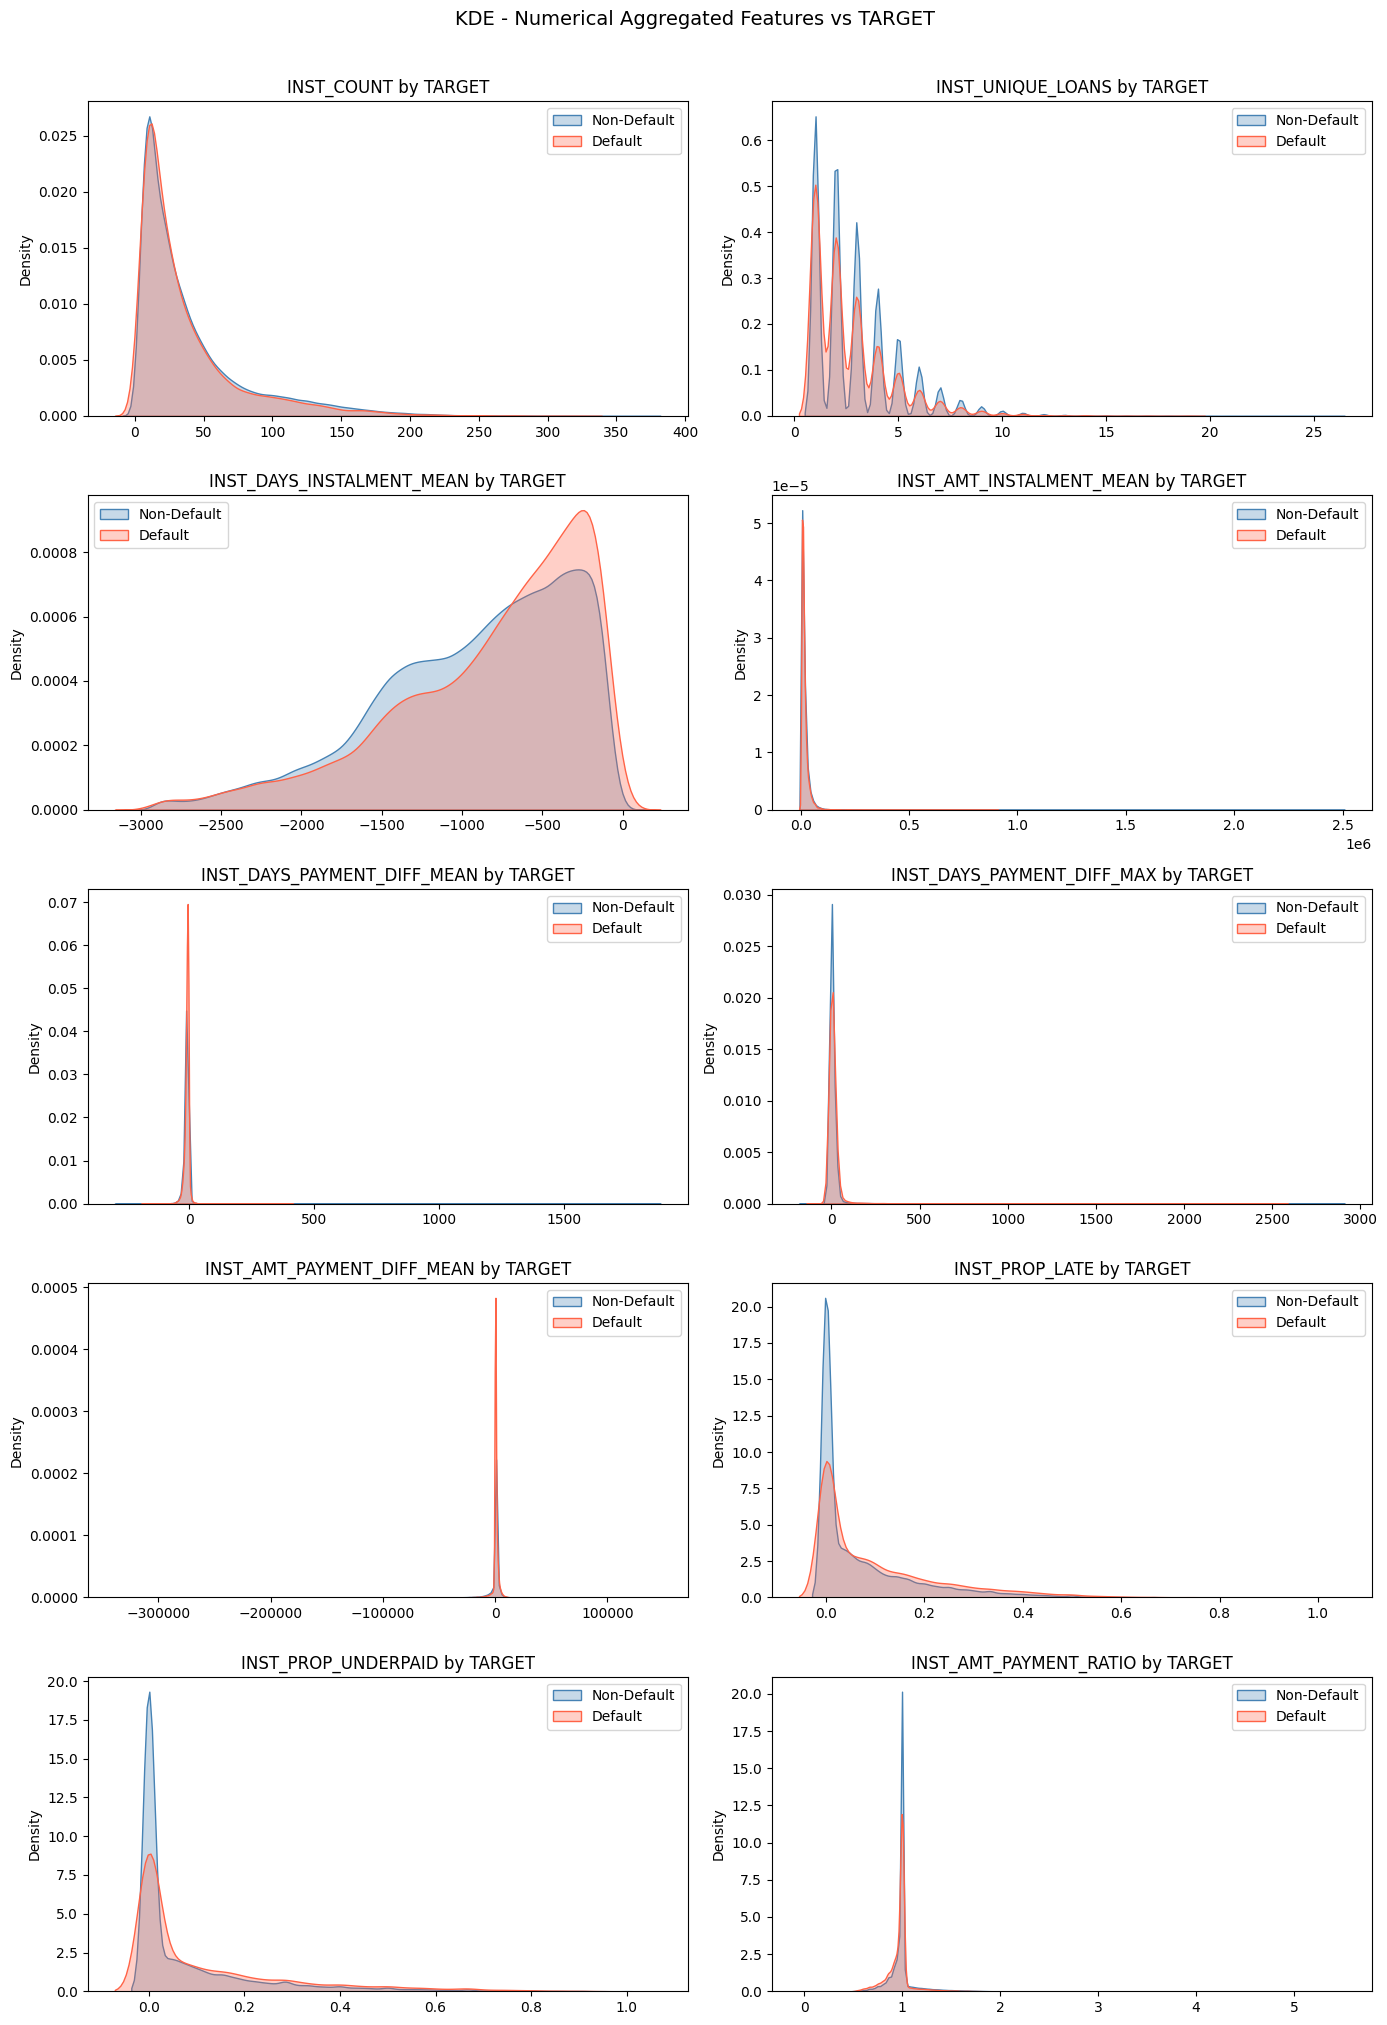

In [17]:
# Select key numerical aggregated features for bivariate analysis
num_agg_features = [
    'INST_COUNT',
    'INST_UNIQUE_LOANS',
    'INST_DAYS_INSTALMENT_MEAN',
    'INST_AMT_INSTALMENT_MEAN',
    'INST_DAYS_PAYMENT_DIFF_MEAN',
    'INST_DAYS_PAYMENT_DIFF_MAX',
    'INST_AMT_PAYMENT_DIFF_MEAN',
    'INST_PROP_LATE',
    'INST_PROP_UNDERPAID',
    'INST_AMT_PAYMENT_RATIO',
]

# Grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_agg_features):
    for target_val, label, color in zip([0, 1], ['Non-Default', 'Default'], ['steelblue', 'tomato']):
        subset = df_inst_agg_target[df_inst_agg_target['TARGET'] == target_val][col].dropna()
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.3)
    axes[i].set_title(f'{col} by TARGET')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.suptitle('KDE - Numerical Aggregated Features vs TARGET', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Key Findings - Numerical Aggregated Features

**INST_COUNT**
Default applicants show higher density at lower installment record counts, while non-default applicants spread toward higher counts. More extensive installment history is associated with lower default risk, consistent with findings across all previous datasets.

**INST_UNIQUE_LOANS**
Default applicants show higher density at 1-2 unique loans while non-default applicants spread more toward higher counts. Having only 1 previous loan is associated with slightly higher default risk.

**INST_DAYS_INSTALMENT_MEAN**
Clear separation between classes. Default applicants show distribution shifted toward more recent installments (less negative), while non-default applicants have older installment history. Longer installment history is consistently associated with lower default risk.

**INST_AMT_INSTALMENT_MEAN**
Both distributions are heavily compressed near zero with extreme right tails. Limited visual separation due to skewness, requires outlier treatment before effective use in modeling.

**INST_DAYS_PAYMENT_DIFF_MEAN and INST_DAYS_PAYMENT_DIFF_MAX**
Both features show distributions heavily compressed near zero with long right tails. Default applicants show slightly heavier tails toward positive values (late payments), but visual separation is limited due to extreme outliers. Non-zero values carry meaningful signal.

**INST_AMT_PAYMENT_DIFF_MEAN**
Both classes are heavily compressed near zero making visual separation difficult. Extreme outliers on both sides confirm the need for capping before modeling.

**INST_PROP_LATE**
Visible separation between classes. Default applicants show a flatter distribution extending toward higher late payment proportions, while non-default applicants peak more sharply near zero. Higher proportion of late payments is associated with higher default risk.

**INST_PROP_UNDERPAID**
Similar pattern to `INST_PROP_LATE` with default applicants showing heavier tails toward higher underpayment proportions. Both proportion features are among the most discriminative aggregated features in this dataset.

**INST_AMT_PAYMENT_RATIO**
Clear separation between classes. Non-default applicants show a strong peak near 1.0 (paying exactly the scheduled amount), while default applicants spread more toward values below 1.0 and above 1.0. A payment ratio consistently near 1.0 is associated with lower default risk.

---

## 6.2 Categorical Aggregated Features

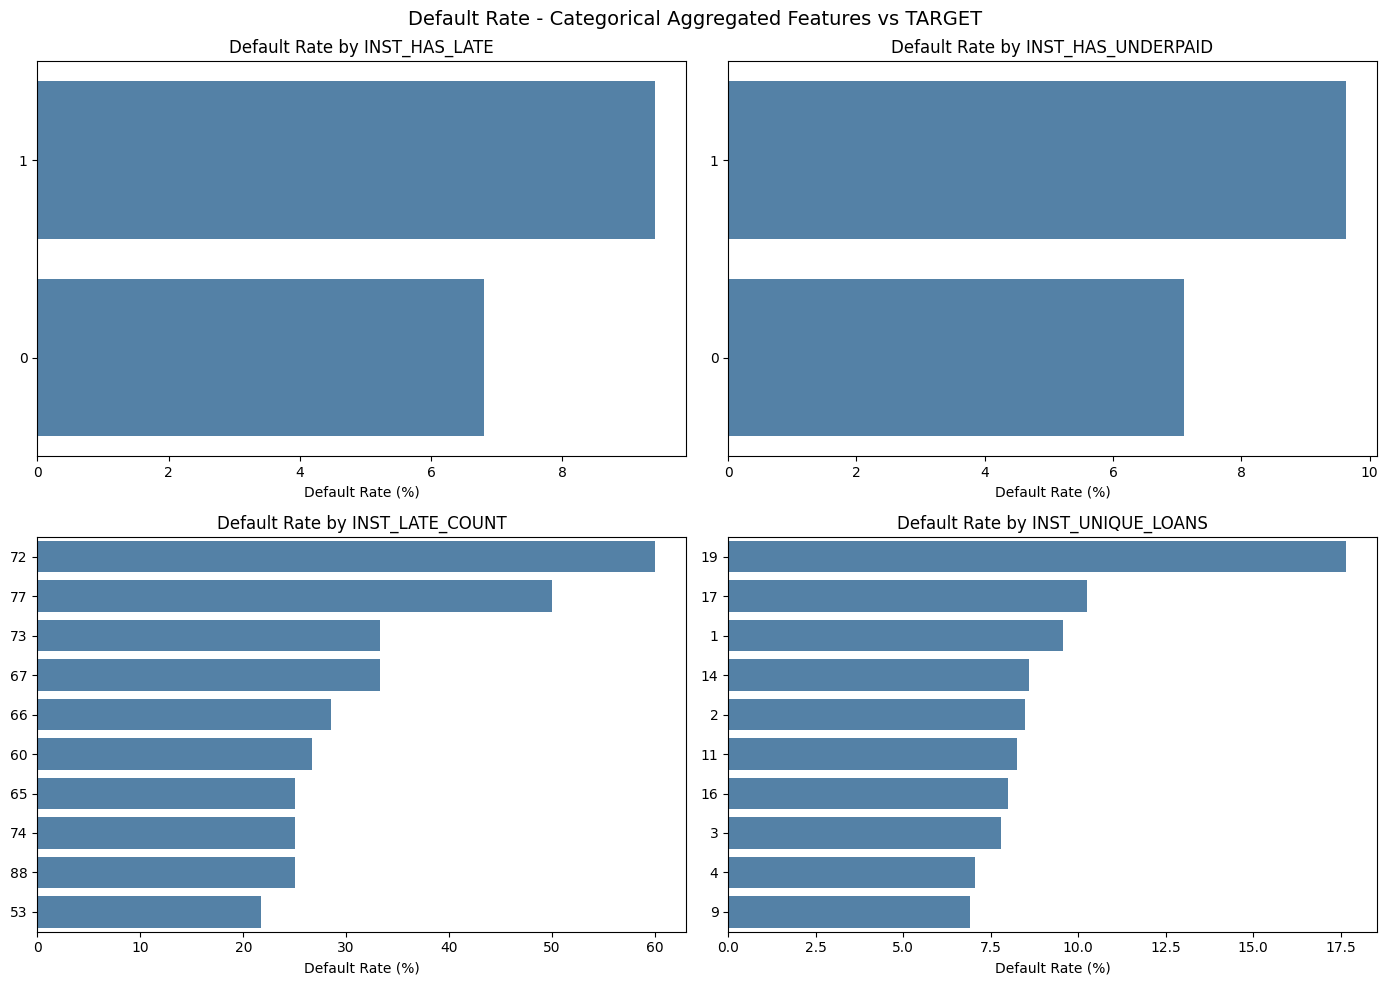

In [18]:
# Select categorical aggregated features for default rate analysis
cat_agg_features = [
    'INST_HAS_LATE',
    'INST_HAS_UNDERPAID',
    'INST_LATE_COUNT',
    'INST_UNIQUE_LOANS',
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_agg_features):
    default_rate = df_inst_agg_target.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False).head(10)
    sns.barplot(x=default_rate.values, y=default_rate.index.astype(str),
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

plt.suptitle('Default Rate - Categorical Aggregated Features vs TARGET', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings - Categorical Aggregated Features

**INST_HAS_LATE**
Applicants with at least one late payment show default rate of ~9% compared to ~7% for those without. The difference is moderate, suggesting late payment history alone is not strongly discriminative but contributes as part of a feature combination.

**INST_HAS_UNDERPAID**
Applicants with at least one underpayment show default rate of ~10% compared to ~7% for those without. Slightly stronger signal than `INST_HAS_LATE`, confirming underpayment behavior is a meaningful risk indicator.

**INST_LATE_COUNT**
Clear positive relationship where higher late payment counts are associated with higher default rates, reaching ~60% at 72 late payments. Confirms that chronic late payment behavior is a strong predictor of default risk.

**INST_UNIQUE_LOANS**
Non-linear relationship where applicants with only 1 unique loan show higher default rate (~10%) while those with moderate counts show lower rates (~8%). Very high unique loan counts (17-19) show elevated rates again, consistent with findings across other datasets.

---

# 7. Insights & Recommendations

## 7.1 Key Findings

**Installment Payment Coverage**
339,587 unique applicants have installment payment records, covering approximately 110% of `application_train` applicants. After merging, applicants with no installment history should be handled with appropriate imputation.

**Late Payment Rate Mirrors Overall Default Rate**
The dataset-level late payment rate of 8.43% closely mirrors the overall default rate in `application_train` (~8.1%), strongly suggesting installment payment behavior is one of the most aligned behavioral signals with default risk across all datasets analyzed.

**Proportion Features are Most Discriminative**
`INST_PROP_LATE` and `INST_PROP_UNDERPAID` show the clearest class separation among all aggregated features, with default applicants showing flatter distributions extending toward higher proportions. These features capture the consistency of payment behavior rather than isolated events and are recommended as priority features for modeling.

**Chronic Late Payment is a Strong Signal**
`INST_LATE_COUNT` shows a clear positive relationship with default rate, reaching ~60% at 72 late payments. Combined with `INST_HAS_LATE` and `INST_PROP_LATE`, late payment behavior provides a multi-dimensional view of repayment discipline that is highly predictive of current default risk.

**Payment Ratio Captures Overall Repayment Discipline**
`INST_AMT_PAYMENT_RATIO` shows clear separation between classes, with non-default applicants consistently paying close to the scheduled amount. This derived feature is among the most informative in the dataset and should be prioritized during feature selection.

**Installment History Depth Matters**
`INST_DAYS_INSTALMENT_MEAN` shows visible class separation consistent with findings across bureau, previous_application, and POS_CASH_balance. Applicants with longer installment histories are consistently associated with lower default risk across all Home Credit datasets.

**Amount Features Require Treatment**
`INST_AMT_INSTALMENT_MEAN`, `INST_AMT_PAYMENT_DIFF_MEAN`, and `INST_AMT_PAYMENT_DIFF_MAX` all show extreme outliers that compress visual class separation. Capping at 99th percentile is required before effective use in modeling.

---


## 7.2 Recommended Aggregated Features

**Count Features:**
- `INST_COUNT`: total installment records per applicant
- `INST_UNIQUE_LOANS`: number of distinct loans with installment history
- `INST_LATE_COUNT`: total count of late payments
- `INST_UNDERPAID_COUNT`: total count of underpayments

**Proportion Features:**
- `INST_PROP_LATE`: proportion of late payments
- `INST_PROP_UNDERPAID`: proportion of underpayments

**Payment Difference Features:**
- `INST_DAYS_PAYMENT_DIFF_MEAN`: average payment delay in days
- `INST_DAYS_PAYMENT_DIFF_MAX`: worst payment delay ever recorded
- `INST_AMT_PAYMENT_DIFF_MEAN`: average underpayment amount
- `INST_AMT_PAYMENT_DIFF_SUM`: total underpayment amount

**Temporal Features:**
- `INST_DAYS_INSTALMENT_MEAN`: average installment recency
- `INST_DAYS_INSTALMENT_MAX`: most recent installment date

**Amount Features:**
- `INST_AMT_INSTALMENT_MEAN`: average scheduled installment amount
- `INST_AMT_PAYMENT_MEAN`: average actual payment amount

**Derived Features Recommended:**
- `INST_AMT_PAYMENT_RATIO`: total payment to total instalment ratio
- `INST_HAS_LATE`: binary flag for ever having a late payment
- `INST_HAS_UNDERPAID`: binary flag for ever having an underpayment

---

## 7.3 Handling Strategy

**Missing Values after Merge:**
- Applicants with no installment records will have all `INST_*` features as NaN after merging. Impute with **0** for count, proportion, and binary flag features, as absence of installment history is a meaningful signal in itself.
- `INST_AMT_PAYMENT_RATIO`: impute with **1** for applicants with no records, reflecting no payment history as neutral, and handle division by zero cases where `INST_AMT_INSTALMENT_SUM` = 0.
- `INST_DAYS_PAYMENT_DIFF_*`: impute with **0** for applicants with no records.

**Outlier Treatment:**
- `INST_AMT_INSTALMENT_MEAN`, `INST_AMT_PAYMENT_MEAN`: cap at 99th percentile
- `INST_DAYS_PAYMENT_DIFF_MAX`: cap at 99th percentile, investigate extreme early payment values
- `INST_AMT_PAYMENT_DIFF_MEAN`, `INST_AMT_PAYMENT_DIFF_MAX`: cap at both 1st and 99th percentile due to bilateral outliers
- `INST_AMT_PAYMENT_RATIO`: cap at 99th percentile to handle extreme overpayment values

**Missed Payment Handling:**
- 2,905 records with missing `DAYS_ENTRY_PAYMENT` and `AMT_PAYMENT` represent missed installments. Impute `AMT_PAYMENT` with **0** and flag these records as missed payments before re-running aggregation in `Data Cleaning and Handling.ipynb`.

**All transformations and imputations to be implemented in `Data Cleaning and Handling.ipynb`.**

---